This notebook generates stats and figure for GCF expression.

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
file_path = '/Users/annasve/Desktop/data/transcriptomics/output/bigscape-2/gcf_3_expression_antismash_corrected.xlsx'
gcf_3 = pd.read_excel(file_path)

In [55]:
file_path = '/Users/annasve/Desktop/data/transcriptomics/output/bigscape-2/gcf_4_expression_antismash_corrected.xlsx'
gcf_4 = pd.read_excel(file_path)

In [56]:
file_path = '/Users/annasve/Desktop/data/transcriptomics/output/bigscape-2/gcf_5_expression_antismash_corrected.xlsx'
gcf_5 = pd.read_excel(file_path)

In [57]:
def classify_families(df, family_col="Family_03", media_col="media_expressed"):
    df = df.copy()
    df.columns = df.columns.str.strip()

    if family_col not in df.columns:
        raise KeyError(
            f"'{family_col}' not found. Available family-like cols: "
            f"{[c for c in df.columns if 'Family' in c]}"
        )

    df["is_expressed"] = df[media_col].fillna("not_expressed") != "not_expressed"

    summary = (
        df.groupby(family_col)["is_expressed"]
        .agg(sum="sum", count="count")
        .reset_index()
    )

    summary["status"] = "Partly expressed"
    summary.loc[summary["sum"] == 0, "status"] = "All silent"
    summary.loc[summary["sum"] == summary["count"], "status"] = "All expressed"

    return summary


In [58]:
s3 = classify_families(gcf_3, family_col = 'Family_03')
s4 = classify_families(gcf_4, family_col = 'Family_04')     
s5 = classify_families(gcf_5, family_col = 'Family_05')     


In [72]:
s3.to_excel('gcf_3_classification.xlsx')

In [73]:
s4.to_excel('gcf_4_classification.xlsx')

In [74]:
s5.to_excel('gcf_5_classification.xlsx')

In [59]:
counts

,status,gcf_0.30,gcf_0.40,gcf_0.50
0,All silent,275,279,277
1,Partly expressed,185,204,244
2,All expressed,145,131,128


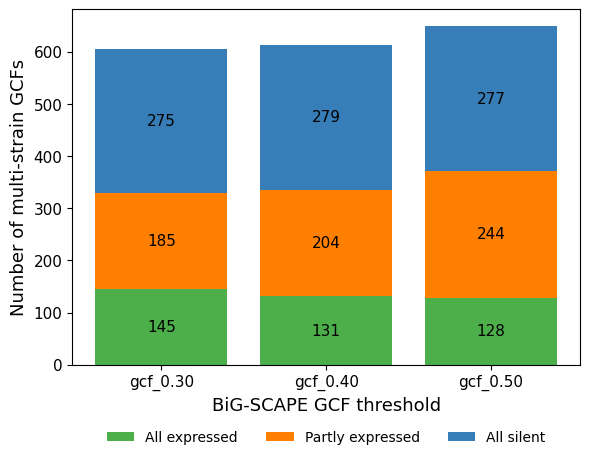

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Build plot_df from s3/s4/s5
plot_df = pd.concat([
    s3["status"].value_counts().rename("gcf_0.30"),
    s4["status"].value_counts().rename("gcf_0.40"),
    s5["status"].value_counts().rename("gcf_0.50"),
], axis=1).fillna(0)

# enforce order (adjust if your exact strings differ)
plot_df = plot_df.reindex(["All expressed", "Partly expressed", "All silent"]).fillna(0)

colors = {
    "All expressed": "#4daf4a",
    "Partly expressed": "#ff7f00",
    "All silent": "#377eb8"
}

fig, ax = plt.subplots(figsize=(6,5))
bottom = [0, 0, 0]

for status in plot_df.index:
    values = plot_df.loc[status].values
    ax.bar(plot_df.columns, values, bottom=bottom, color=colors[status], label=status)

    for i, v in enumerate(values):
        ax.text(i, bottom[i] + v/2, f"{int(v)}",
                ha="center", va="center", fontsize=11, color="black")

    bottom = [bottom[i] + values[i] for i in range(len(values))]

ax.set_ylabel("Number of multi-strain GCFs", fontsize=13)
ax.set_xlabel("BiG-SCAPE GCF threshold", fontsize=13)
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)

ax.tick_params(labelsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 1])

# SAVE FIRST
plt.savefig("gcf_expression_barplot.png", dpi=350, bbox_inches="tight")

# THEN SHOW
plt.show()





In [70]:
plot_df

,gcf_0.30,gcf_0.40,gcf_0.50
status,,,
All expressed,145,131,128
Partly expressed,185,204,244
All silent,275,279,277
